# Tarea 04 — Visualización de Datos con Matplotlib

**Instrucciones:** Completa cada celda de código con tu respuesta.  
Usarás la interfaz orientada a objetos de Matplotlib (`fig, ax = plt.subplots()`).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dataset de trabajo
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

---
## Parte 1 — Figura y ejes

**P1.** Crea una figura con `plt.subplots()` de tamaño 8×5.  
Haz un gráfico de línea con los primeros 20 valores de `sepal_length`.  
Agrega título `"Longitud del sépalo"` y etiquetas en ambos ejes.

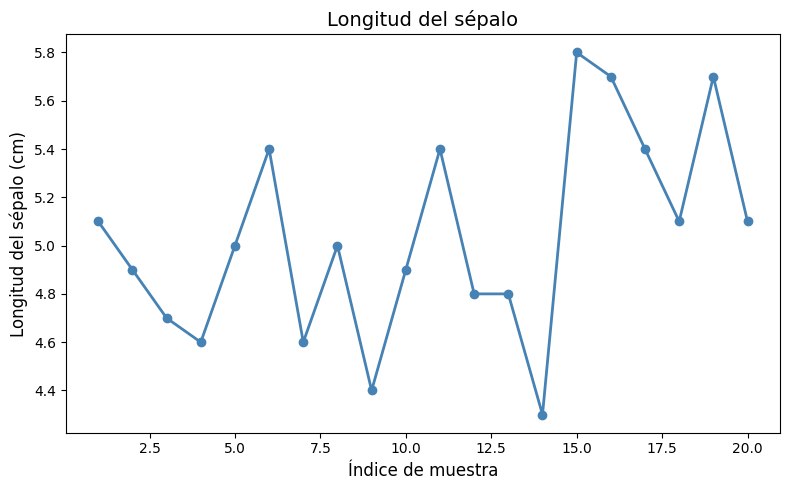

In [2]:
# Tu respuesta aquí
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 21), df['sepal_length'].head(20), marker='o', color='steelblue', linewidth=2)
ax.set_title("Longitud del sépalo", fontsize=14)
ax.set_xlabel("Índice de muestra", fontsize=12)
ax.set_ylabel("Longitud del sépalo (cm)", fontsize=12)

plt.tight_layout()
plt.show()

---
## Parte 2 — Gráfico de barras

**P2.** Calcula el promedio de `petal_length` por especie (`species`) y guárdalo en una variable.  
Luego crea un **gráfico de barras vertical** con esos promedios.  
Agrega título y etiquetas en ambos ejes.

species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal_length, dtype: float64


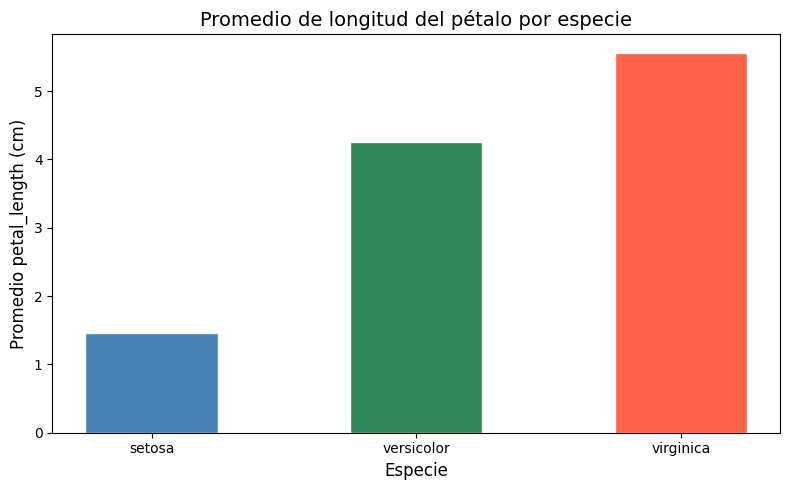

In [3]:
# Tu respuesta aquí
promedio_por_especie = df.groupby('species')['petal_length'].mean()

print(promedio_por_especie)


fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(promedio_por_especie.index, promedio_por_especie.values,
       color=['steelblue', 'seagreen', 'tomato'], edgecolor='white', width=0.5)

ax.set_title("Promedio de longitud del pétalo por especie", fontsize=14)
ax.set_xlabel("Especie", fontsize=12)
ax.set_ylabel("Promedio petal_length (cm)", fontsize=12)

plt.tight_layout()
plt.show()

---
## Parte 3 — Dispersión (scatter plot)

**P3.** Crea un **gráfico de dispersión** (scatter) con `sepal_length` en el eje X y `sepal_width` en el eje Y.  
Usa un color diferente para cada especie (puedes filtrar el DataFrame tres veces o usar un bucle).  
Agrega leyenda, título y etiquetas.

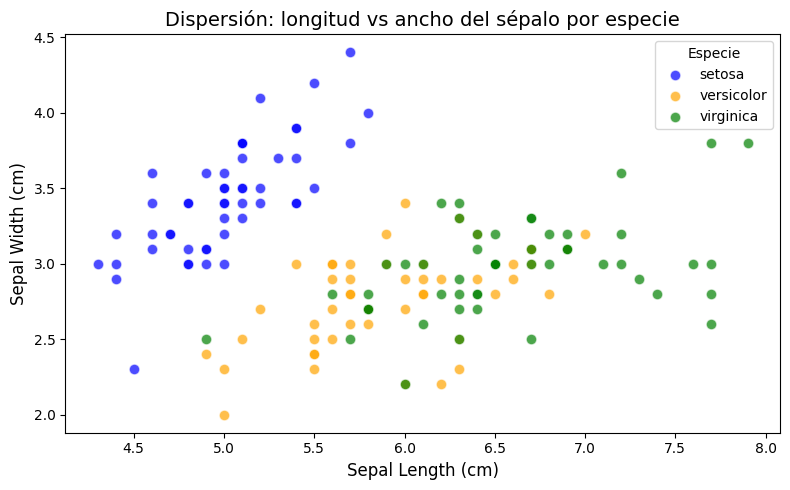

In [4]:
especies = df["species"].unique()
colores = ["blue", "orange", "green"]

fig, ax = plt.subplots(figsize=(8, 5))

# Tu respuesta aquí: itera sobre especies y colores para graficar cada grupo
for especie, color in zip(especies, colores):
    subset = df[df["species"] == especie]
    ax.scatter(subset["sepal_length"], subset["sepal_width"],
               label=especie, color=color, alpha=0.7, edgecolors='white', s=60)

ax.set_title("Dispersión: longitud vs ancho del sépalo por especie", fontsize=14)
ax.set_xlabel("Sepal Length (cm)", fontsize=12)
ax.set_ylabel("Sepal Width (cm)", fontsize=12)
ax.legend(title="Especie", fontsize=10)

plt.tight_layout()
plt.show()

---
## Parte 4 — Histograma

**P4.** Crea un **histograma** de la columna `petal_width` con 15 bins.  
Agrega una línea vertical punteada en el valor de la media con `ax.axvline()`.  
Agrega título y etiquetas.

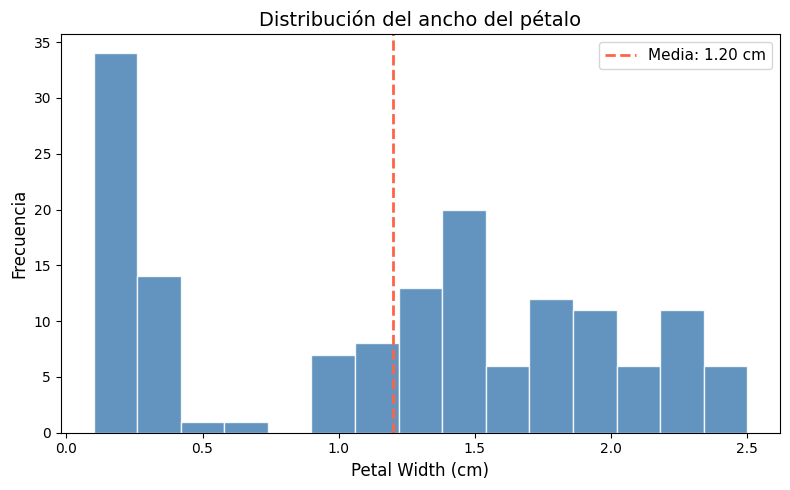

In [5]:
# Tu respuesta aquí

media = df["petal_width"].mean()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df["petal_width"], bins=15, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(media, color="tomato", linestyle="--", linewidth=2,
           label=f"Media: {media:.2f} cm")

ax.set_title("Distribución del ancho del pétalo", fontsize=14)
ax.set_xlabel("Petal Width (cm)", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

---
## Parte 5 — Guardar figura

**P5.** Recrea el gráfico de barras de P2 y guárdalo como imagen PNG en `output/promedios_iris.png`.  
Usa `dpi=100` y `bbox_inches="tight"`.

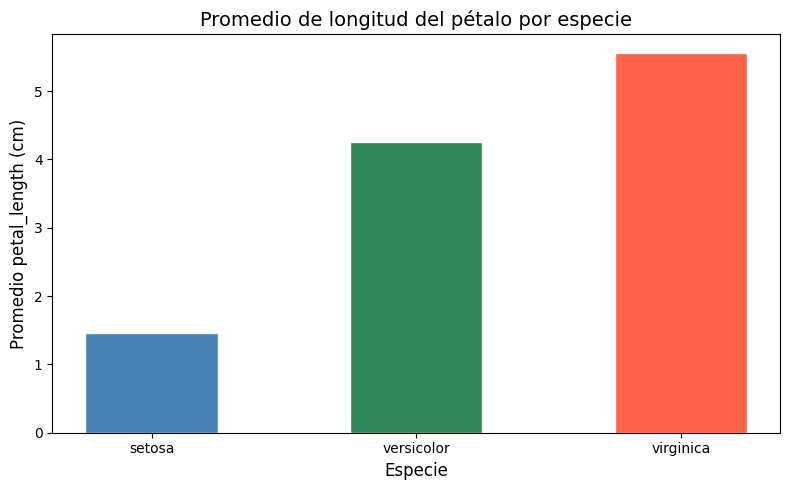

La imagen fue guardada en: output/promedios_iris.png


In [6]:
import os
os.makedirs("output", exist_ok=True)

# Tu respuesta aquí
promedio_por_especie = df.groupby('species')['petal_length'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(promedio_por_especie.index, promedio_por_especie.values,
       color=['steelblue', 'seagreen', 'tomato'], edgecolor='white', width=0.5)
ax.set_title("Promedio de longitud del pétalo por especie", fontsize=14)
ax.set_xlabel("Especie", fontsize=12)
ax.set_ylabel("Promedio petal_length (cm)", fontsize=12)

plt.tight_layout()
plt.savefig("output/promedios_iris.png", dpi=100, bbox_inches="tight")
plt.show()

print("La imagen fue guardada en: output/promedios_iris.png")